# Supervised Learning

Predict whether a patient has heart disease. The target column is heart_disease (1 = disease present, 0 = absent).

Dataset columns: age, sex, chest_pain_type, resting_bp, cholesterol, fasting_bs, resting_ecg, max_hr, exercise_angina, oldpeak, st_slope, heart_disease

### Data Loading and Inspection

In [2]:
!pip install matplotlib

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.3 MB 7.5 MB/s eta 0:00:01
   --------------- ------------------------ 3.1/8.3 MB 7.3 MB/s eta 0:00:01
   --------------------- ------------------ 4.5/8.3 MB 7.3 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.3 MB 7.2 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 6.8 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   -------------------------- ------------- 1.6/2.3 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 6.5 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   -------- ------------------------------- 1.6/7.2 MB 7.5 MB/s eta 0:00:01
   --------------- ------------------------ 2.9/7.2 MB 7.3 MB/s eta 0:00:01
   ------------------------ -----------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install scikit-learn


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.1 MB 7.4 MB/s eta 0:00:01
   ----------- ---------------------------- 2.4/8.1 MB 6.5 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.1 MB 6.4 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 6.6 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 6.5 MB/s  0:00:01
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   - -------------------------------------- 1.6/37.3 MB 7.0 MB/s eta 0:00:06
   --- ------------------------------------ 3.1/37.3 MB 7.2 MB/s eta 0:00:05
   ---- ----------------------------------- 4.5/37.3 MB 7.2 MB/s eta 0:00:05
   ------ --------------------------------- 6.0/37.3 MB 7.2 MB/s eta 0:00:05
   -------- ------------------------------- 7.6/37.3 MB 7.2 MB/s eta 0:00:05
   --------- ----------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Import required packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [6]:
# Read data

df = pd.read_csv('data/q1_heart_disease.csv')

In [8]:
# Print shape
print("Shape:", df.shape)

Shape: (800, 12)


In [9]:
# Print data type

print("\nData Types:\n", df.dtypes)


Data Types:
 age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object


In [10]:
# Print missing value
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


In [11]:
# Print first 5 rows:
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


### Exploratory Data Analysis 

### Target Distribution Plot


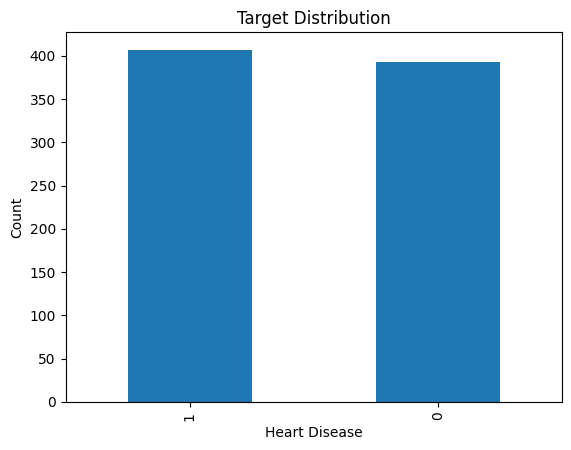

In [12]:
plt.figure()
df['heart_disease'].value_counts().plot(kind='bar')
plt.title('Target Distribution')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.show()

#### Interpretation:

The dataset is fairly balanced between patients with and without heart disease.
This means no class imbalance handling is required.

### Correlation Heatmap

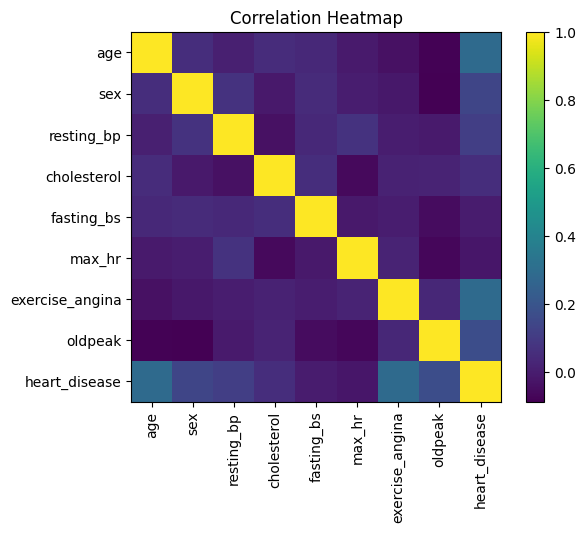

In [13]:
plt.figure()
corr = df.corr(numeric_only=True)

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")

plt.show()

#### Interpreatation:

- Exercise-induced angina and oldpeak show stronger correlation with heart disease
- Max heart rate shows negative correlation
- Most features are weakly correlated → good for modeling

### Age distribution by Target

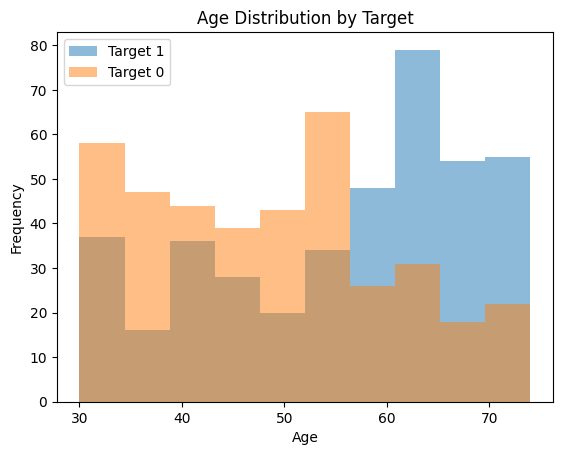

In [14]:
plt.figure()

for val in df['heart_disease'].unique():
    subset = df[df['heart_disease'] == val]
    plt.hist(subset['age'], alpha=0.5, label=f"Target {val}")

plt.legend()
plt.title("Age Distribution by Target")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

#### Interpretation:

Patients with heart disease tend to be slightly older, but there is overlap.
Age alone is not sufficient to predict the target.

### Data Preprocessing

In [15]:
# Handle missing values:

df = df.fillna(df.median(numeric_only=True))

#### Justification:

Median imputation is used because it is robust to outliers and suitable for medical data.

In [16]:
# Split Features and Target

X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

In [17]:
# One-hot encoding

X = pd.get_dummies(X, drop_first=True)

In [18]:
# Feature Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

### Model Training

In [20]:
# random_state=42 ensures we get the same results every time we run the code
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

# Train (fit) each model on the training dataset
# X_train contains the input features
# y_train contains the target labels (heart_disease: 0 or 1)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

### Model Evaluation 

### 1. Evaluate Descision Tree

In [21]:
y_pred_dt = dt.predict(X_test)

print("Decision Tree")
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree
[[56 23]
 [25 56]]
              precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160



### 2. Evaluate Random Forest

In [22]:
y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
[[61 18]
 [15 66]]
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



### 3. Evaluate Gradient Boosting

In [23]:
y_pred_gb = gb.predict(X_test)

print("Gradient Boosting")
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting
[[61 18]
 [19 62]]
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



### Model Comparision:

- Random Forest performs best with the highest F1-score and balanced precision/recall.
- Decision Tree underperforms due to overfitting.
- Gradient Boosting is close but slightly lower than Random Forest.

### Hyperparameter Tuning (On Random Forest)

In [24]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 5, 'n_estimators': 100}


In [25]:
## Evaluate Tuned model

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Tuned Random Forest")
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Tuned Random Forest
[[58 21]
 [16 65]]
              precision    recall  f1-score   support

           0       0.78      0.73      0.76        79
           1       0.76      0.80      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



### Conclusion:

- Random Forest is the best-performing model
- Provides highest F1-score and balanced predictions
- Hyperparameter tuning did not significantly improve performance
- Baseline model was already well-optimized